In [3]:
# Step 1: Map your problem to a quantum circuit

# Import some general packages
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
import numpy as np

In [4]:
# Define registers
secret = QuantumRegister(1, "Q")
Alice = QuantumRegister(1, "A")
Bob = QuantumRegister(1, "B")

cr = ClassicalRegister(3, "c")

qc = QuantumCircuit(secret, Alice, Bob, cr)


In [5]:
# We entangle Alice's and Bob's qubits as in our work above. We apply a Hadamard gate and then a CNOT gate.
# Note that the second argument in the CNOT gate is the target.
qc.h(Alice)
qc.cx(Alice, Bob)

# Inserting a barrier changes nothing about the logic. It just allows us to force gates to be positioned in "layers".
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "Q"), index=0>, <Qubit register=(1, "A"), index=0>, <Qubit register=(1, "B"), index=0>), clbits=())

In [6]:
# Now we will use random variables to create the secret state. Don't worry about the "u" gate and the details.
np.random.seed(42)  # fixing seed for repeatability
theta = np.random.uniform(0.0, 1.0) * np.pi  # from 0 to pi
varphi = np.random.uniform(0.0, 2.0) * np.pi  # from 0 to 2*pi

# Assign the secret state to the qubit on the other side of Alice's (qubit 0), labeled Q
qc.u(theta, varphi, 0.0, secret)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "Q"), index=0>, <Qubit register=(1, "A"), index=0>, <Qubit register=(1, "B"), index=0>), clbits=())

In [7]:
# Now entangle Q and Alice's qubits as in the discussion above.
qc.cx(secret, Alice)
qc.h(secret)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "Q"), index=0>, <Qubit register=(1, "A"), index=0>, <Qubit register=(1, "B"), index=0>), clbits=())

In [8]:
# Now Alice measures her qubits, and stores the outcomes in the "classical registers" cr[]
qc.measure(Alice, cr[1])
qc.measure(secret, cr[0])

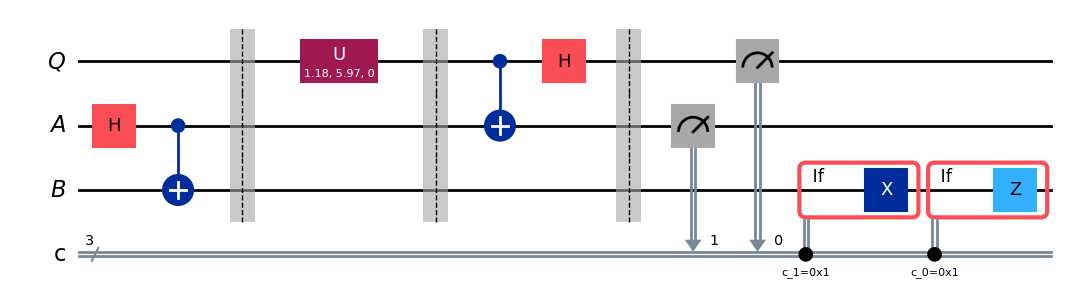

In [9]:
# Now we insert some conditional logic. If Alice measures Q in a "1" we need a Z gate, and if Alice measures A in a "1" we need an X gate (see the table).
with qc.if_test((cr[1], 1)):
    qc.x(Bob)
with qc.if_test((cr[0], 1)):
    qc.z(Bob)

qc.draw(output="mpl")

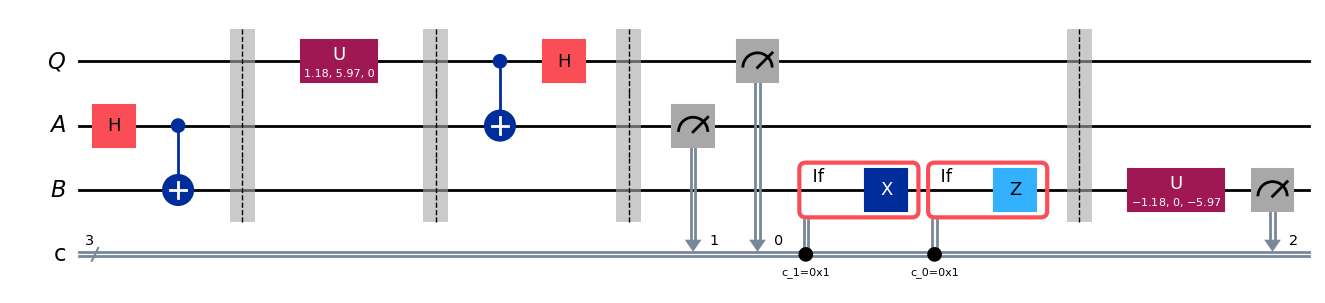

In [10]:
# Add the inverse of U and measure Bob's qubit.
qc.barrier()

qc.u(theta, varphi, 0.0, Bob).inverse()  # inverse of u(theta,varphi,0.0)
qc.measure(Bob, cr[2])  # add measurement gate

qc.draw(output="mpl")

In [12]:
# 2.teleportation across processors
# Step 1: Map

# Define registers
qr = QuantumRegister(13, "q")

qc = QuantumCircuit(qr, cr)

# Define registers
secret = QuantumRegister(1, "Q")
ebitsa = QuantumRegister(6, "A")
ebitsb = QuantumRegister(6, "B")
# q = ClassicalRegister(1, "q meas")
# a = ClassicalRegister(1, "a")
# b = ClassicalRegister(1, "b")
cr = ClassicalRegister(3, "c")
qc = QuantumCircuit(secret, ebitsa, ebitsb, cr)
#

In [13]:
# We'll start Alice in the middle of the circuit, then move information outward in both directions.
Alice = 5
Bob = 0
qc.h(ebitsa[Alice])
qc.cx(ebitsa[Alice], ebitsb[Bob])

In [14]:
# Starting with Bob and Alice in the center, we swap their information onto adjacent qubits, until the information is on distant qubits.

for n in range(Alice):
    qc.swap(ebitsb[Bob], ebitsb[Bob + 1])
    qc.swap(ebitsa[Alice], ebitsa[Alice - 1])
    Alice = Alice - 1
    Bob = Bob + 1

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=13, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "Q"), index=0>, <Qubit register=(6, "A"), index=0>, <Qubit register=(6, "A"), index=1>, <Qubit register=(6, "A"), index=2>, <Qubit register=(6, "A"), index=3>, <Qubit register=(6, "A"), index=4>, <Qubit register=(6, "A"), index=5>, <Qubit register=(6, "B"), index=0>, <Qubit register=(6, "B"), index=1>, <Qubit register=(6, "B"), index=2>, <Qubit register=(6, "B"), index=3>, <Qubit register=(6, "B"), index=4>, <Qubit register=(6, "B"), index=5>), clbits=())

In [15]:
# Create a random state for Alice (qubit zero)
np.random.seed(42)  # fixing seed for repeatability
# theta = np.random.uniform(0.0, 1.0) * np.pi    #from 0 to pi
theta = 0.3
varphi = np.random.uniform(0.0, 2.0) * np.pi  # from 0 to 2*pi


qc.u(theta, varphi, 0.0, secret)


In [16]:
# Entangle Alice's two qubits
qc.cx(secret, ebitsa[Alice])
qc.h(secret)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=13, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "Q"), index=0>, <Qubit register=(6, "A"), index=0>, <Qubit register=(6, "A"), index=1>, <Qubit register=(6, "A"), index=2>, <Qubit register=(6, "A"), index=3>, <Qubit register=(6, "A"), index=4>, <Qubit register=(6, "A"), index=5>, <Qubit register=(6, "B"), index=0>, <Qubit register=(6, "B"), index=1>, <Qubit register=(6, "B"), index=2>, <Qubit register=(6, "B"), index=3>, <Qubit register=(6, "B"), index=4>, <Qubit register=(6, "B"), index=5>), clbits=())

In [17]:
# Make measurements of Alice's qubits and store the results in the classical register.
qc.measure(ebitsa[Alice], cr[1])
qc.measure(secret, cr[0])

# Send instructions to Bob's qubits based on the outcome of Alice's measurements.
with qc.if_test((cr[1], 1)):
    qc.x(ebitsb[Bob])
with qc.if_test((cr[0], 1)):
    qc.z(ebitsb[Bob])

qc.barrier()


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=13, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "Q"), index=0>, <Qubit register=(6, "A"), index=0>, <Qubit register=(6, "A"), index=1>, <Qubit register=(6, "A"), index=2>, <Qubit register=(6, "A"), index=3>, <Qubit register=(6, "A"), index=4>, <Qubit register=(6, "A"), index=5>, <Qubit register=(6, "B"), index=0>, <Qubit register=(6, "B"), index=1>, <Qubit register=(6, "B"), index=2>, <Qubit register=(6, "B"), index=3>, <Qubit register=(6, "B"), index=4>, <Qubit register=(6, "B"), index=5>), clbits=())

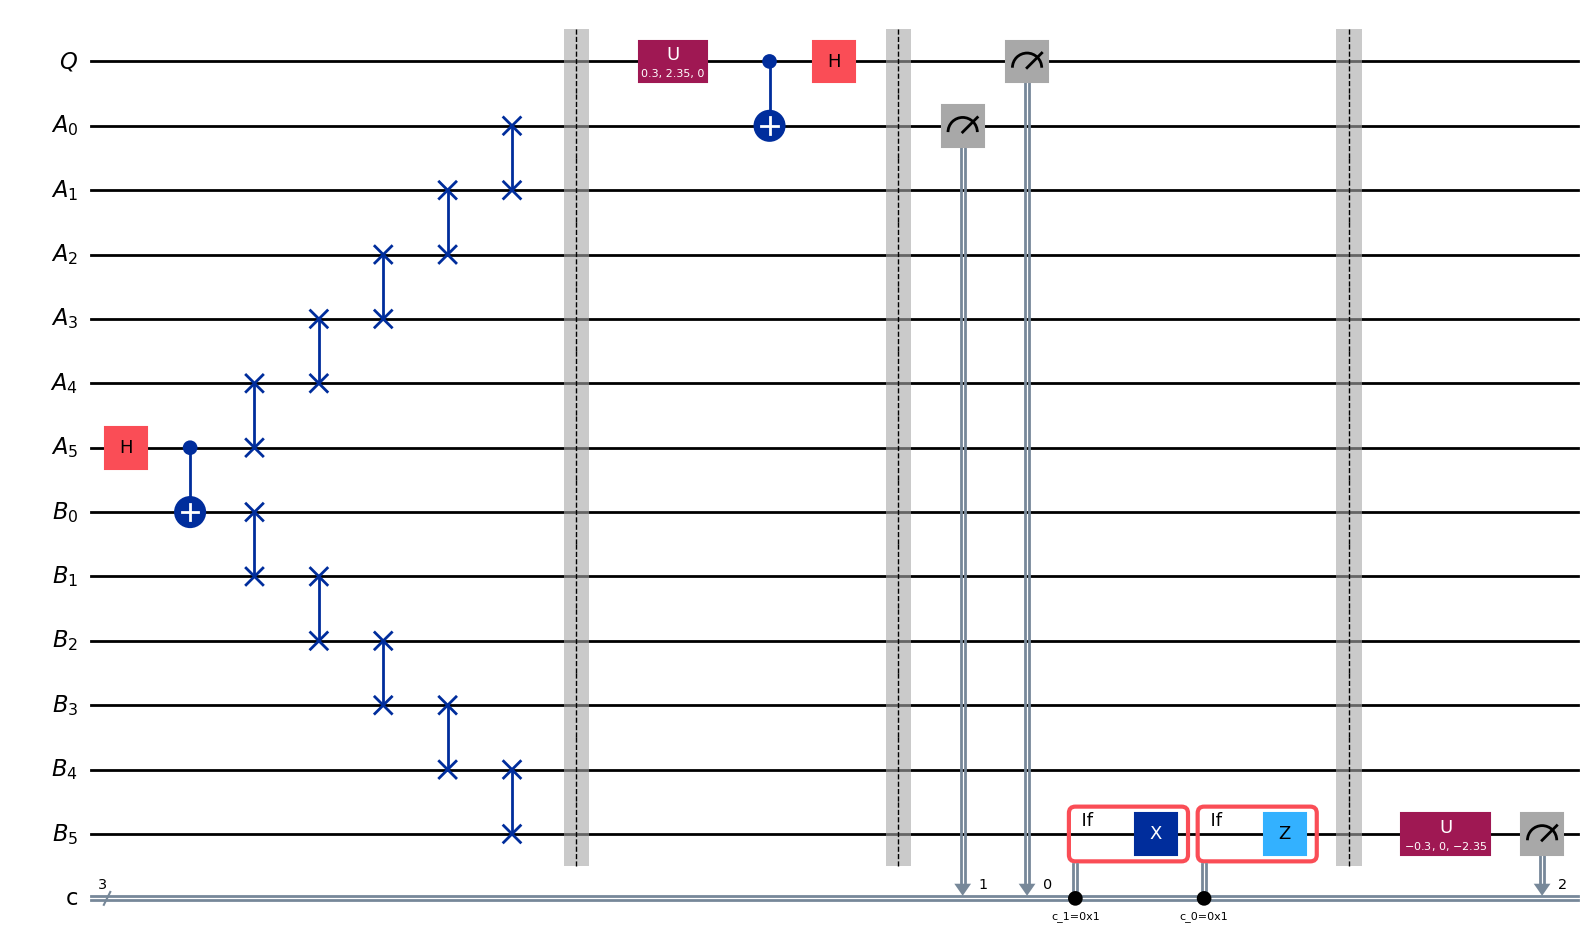

In [18]:
# Invert the preparation we did for Carl's qubit so we can check whether we did this correctly.
qc.u(theta, varphi, 0.0, ebitsb[Bob]).inverse()  # inverse of u(theta,varphi,0.0)
qc.measure(ebitsb[Bob], cr[2])  # add measurement gate

qc.draw("mpl")